<a href="https://colab.research.google.com/github/M356953/ICTAK_AI_ML/blob/main/Artificial_Intelligence_and_Machine_Learning_Exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
df=pd.read_csv('/content/sample_data/dataset_loan.csv')

In [9]:
newApp_df=pd.read_csv('/content/sample_data/new_applications.csv')

In [10]:
cust_df=pd.read_csv('/content/sample_data/customer_remarks.csv')

In [13]:

import os

print(os.listdir('/content'))

['.config', 'sample_data', '.ipynb_checkpoints', 'drive']


In [14]:
import pandas as pd

# Load datasets
df = pd.read_csv('/content/sample_data/dataset_loan.csv')
remarks_df = pd.read_csv('/content/sample_data/new_applications.csv')
new_df = pd.read_csv('/content/sample_data/customer_remarks.csv')

# Display first few rows
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:

print("Loan Dataset Shape:", df.shape)
print("Customer Remarks Shape:", remarks_df.shape)
print("New Applications Shape:", new_df.shape)

Loan Dataset Shape: (66997, 122)
Customer Remarks Shape: (10, 17)
New Applications Shape: (15, 2)


Task 1: Data Exploration and Preparation


In [16]:
import pandas as pd
import numpy as np

print("=" * 70)
print("LOAN APPLICATION DATASET OVERVIEW")
print("=" * 70)

# Dataset Shape
print("\n1. Dataset Shape")
print("-" * 40)
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

# Display First Five Records
print("\n2. First Five Records")
print("-" * 40)
display(df.head())

# Display Last Five Records
print("\n3. Last Five Records")
print("-" * 40)
display(df.tail())

# Dataset Information
print("\n4. Dataset Information")
print("-" * 40)
df.info()

# Numerical Statistics
print("\n5. Statistical Summary (Numerical Features)")
print("-" * 40)
display(df.describe().T)

# Categorical Statistics
print("\n6. Statistical Summary (Categorical Features)")
print("-" * 40)

categorical_cols = df.select_dtypes(include=['object']).columns

if len(categorical_cols) > 0:
    display(df[categorical_cols].describe().T)
else:
    print("No categorical columns found.")

# Column Names
print("\n7. Column Names")
print("-" * 40)

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

# Data Types Summary
print("\n8. Data Types Summary")
print("-" * 40)

dtype_summary = df.dtypes.value_counts()

display(dtype_summary)

# Numerical & Categorical Features
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("\n9. Feature Type Summary")
print("-" * 40)

print(f"Numerical Features   : {len(numerical_columns)}")
print(f"Categorical Features : {len(categorical_columns)}")

# Target Variable
print("\n10. Target Variable")
print("-" * 40)

if 'TARGET' in df.columns:
    print("Target Variable : TARGET")
    print(df['TARGET'].value_counts())
else:
    print("TARGET column not found.")

# Identifier Columns
print("\n11. Possible Identifier Columns")
print("-" * 40)

id_columns = [col for col in df.columns if 'ID' in col.upper()]

if len(id_columns) > 0:
    print(id_columns)
else:
    print("No identifier columns detected.")

print("\nDataset Understanding Completed Successfully.")

LOAN APPLICATION DATASET OVERVIEW

1. Dataset Shape
----------------------------------------
Number of Rows    : 66997
Number of Columns : 122

2. First Five Records
----------------------------------------


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0



3. Last Five Records
----------------------------------------


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
66992,177681,0,Revolving loans,F,Y,Y,1,157500.0,315000.0,15750.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,3.0
66993,177682,0,Cash loans,F,N,Y,0,90000.0,450000.0,17095.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
66994,177683,0,Cash loans,F,N,N,0,135000.0,254700.0,27558.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
66995,177684,0,Cash loans,F,Y,Y,0,112500.0,835506.0,30825.0,...,0,0,0,0,0.0,0.0,0.0,0.0,2.0,1.0
66996,177685,0,Revolving loans,F,Y,Y,0,67500.0,180000.0,9000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,3.0,2.0



4. Dataset Information
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66997 entries, 0 to 66996
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(64), int64(42), object(16)
memory usage: 62.4+ MB

5. Statistical Summary (Numerical Features)
----------------------------------------


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,66997.0,138854.767751,22385.440990,100002.0,119534.0,138803.0,158171.0,177685.0
TARGET,66997.0,0.080556,0.272154,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,66997.0,0.419302,0.724611,0.0,0.0,0.0,1.0,11.0
AMT_INCOME_TOTAL,66997.0,169651.169325,461832.302331,25650.0,112500.0,144000.0,202500.0,117000000.0
AMT_CREDIT,66997.0,599157.003694,402373.391281,45000.0,270000.0,513040.5,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,58030.0,0.007600,0.110274,0.0,0.0,0.0,0.0,6.0
AMT_REQ_CREDIT_BUREAU_WEEK,58030.0,0.032948,0.198783,0.0,0.0,0.0,0.0,6.0
AMT_REQ_CREDIT_BUREAU_MON,58030.0,0.268654,0.925676,0.0,0.0,0.0,0.0,24.0
AMT_REQ_CREDIT_BUREAU_QRT,58030.0,0.264174,0.612335,0.0,0.0,0.0,0.0,8.0



6. Statistical Summary (Categorical Features)
----------------------------------------


,count,unique,top,freq
NAME_CONTRACT_TYPE,66997,2,Cash loans,60665
CODE_GENDER,66997,3,F,44037
FLAG_OWN_CAR,66997,2,N,44222
FLAG_OWN_REALTY,66997,2,Y,46498
NAME_TYPE_SUITE,66727,7,Unaccompanied,54157
NAME_INCOME_TYPE,66997,8,Working,34743
NAME_EDUCATION_TYPE,66997,5,Secondary / secondary special,47679
NAME_FAMILY_STATUS,66997,6,Married,42896
NAME_HOUSING_TYPE,66997,6,House / apartment,59482
OCCUPATION_TYPE,46030,18,Laborers,12012



7. Column Names
----------------------------------------
1. SK_ID_CURR
2. TARGET
3. NAME_CONTRACT_TYPE
4. CODE_GENDER
5. FLAG_OWN_CAR
6. FLAG_OWN_REALTY
7. CNT_CHILDREN
8. AMT_INCOME_TOTAL
9. AMT_CREDIT
10. AMT_ANNUITY
11. AMT_GOODS_PRICE
12. NAME_TYPE_SUITE
13. NAME_INCOME_TYPE
14. NAME_EDUCATION_TYPE
15. NAME_FAMILY_STATUS
16. NAME_HOUSING_TYPE
17. REGION_POPULATION_RELATIVE
18. DAYS_BIRTH
19. DAYS_EMPLOYED
20. DAYS_REGISTRATION
21. DAYS_ID_PUBLISH
22. OWN_CAR_AGE
23. FLAG_MOBIL
24. FLAG_EMP_PHONE
25. FLAG_WORK_PHONE
26. FLAG_CONT_MOBILE
27. FLAG_PHONE
28. FLAG_EMAIL
29. OCCUPATION_TYPE
30. CNT_FAM_MEMBERS
31. REGION_RATING_CLIENT
32. REGION_RATING_CLIENT_W_CITY
33. WEEKDAY_APPR_PROCESS_START
34. HOUR_APPR_PROCESS_START
35. REG_REGION_NOT_LIVE_REGION
36. REG_REGION_NOT_WORK_REGION
37. LIVE_REGION_NOT_WORK_REGION
38. REG_CITY_NOT_LIVE_CITY
39. REG_CITY_NOT_WORK_CITY
40. LIVE_CITY_NOT_WORK_CITY
41. ORGANIZATION_TYPE
42. EXT_SOURCE_1
43. EXT_SOURCE_2
44. EXT_SOURCE_3
45. APARTMENTS_AVG

,count
float64,64
int64,42
object,16



9. Feature Type Summary
----------------------------------------
Numerical Features   : 106
Categorical Features : 16

10. Target Variable
----------------------------------------
Target Variable : TARGET
TARGET
0    61600
1     5397
Name: count, dtype: int64

11. Possible Identifier Columns
----------------------------------------
['SK_ID_CURR', 'DAYS_ID_PUBLISH']

Dataset Understanding Completed Successfully.


In [17]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 66997
Number of Columns : 122


In [18]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
df.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
66992,177681,0,Revolving loans,F,Y,Y,1,157500.0,315000.0,15750.0,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,3.0
66993,177682,0,Cash loans,F,N,Y,0,90000.0,450000.0,17095.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
66994,177683,0,Cash loans,F,N,N,0,135000.0,254700.0,27558.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0
66995,177684,0,Cash loans,F,Y,Y,0,112500.0,835506.0,30825.0,...,0,0,0,0,0.0,0.0,0.0,0.0,2.0,1.0
66996,177685,0,Revolving loans,F,Y,Y,0,67500.0,180000.0,9000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,3.0,2.0


In [20]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 66997
Number of Columns : 122


In [21]:
df.columns


Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [22]:
df.shape

(66997, 122)

In [23]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66997 entries, 0 to 66996
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(64), int64(42), object(16)
memory usage: 62.4+ MB


In [24]:

df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,66997.000000,66997.000000,66997.000000,6.699700e+04,6.699700e+04,66992.000000,6.694300e+04,66997.000000,66997.000000,66997.000000,...,66997.000000,66997.000000,66997.000000,66997.000000,58030.000000,58030.000000,58030.000000,58030.000000,58030.000000,58030.000000
mean,138854.767751,0.080556,0.419302,1.696512e+05,5.991570e+05,27076.863133,5.384704e+05,0.020863,-16025.031061,63166.594400,...,0.008314,0.000702,0.000448,0.000328,0.007100,0.007600,0.032948,0.268654,0.264174,1.885783
std,22385.440990,0.272154,0.724611,4.618323e+05,4.023734e+05,14496.126431,3.696315e+05,0.013764,4361.902674,140748.150411,...,0.090801,0.026477,0.021156,0.018118,0.088556,0.110274,0.198783,0.925676,0.612335,1.870716
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,2052.000000,4.500000e+04,0.000533,-25201.000000,-17531.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,119534.000000,0.000000,0.000000,1.125000e+05,2.700000e+05,16456.500000,2.385000e+05,0.010006,-19654.000000,-2787.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,138803.000000,0.000000,0.000000,1.440000e+05,5.130405e+05,24907.500000,4.500000e+05,0.018850,-15745.000000,-1218.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,158171.000000,0.000000,1.000000,2.025000e+05,8.086500e+05,34587.000000,6.795000e+05,0.028663,-12386.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,177685.000000,1.000000,11.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7676.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,3.000000,6.000000,6.000000,24.000000,8.000000,25.000000


In [25]:

df.describe(include='object')

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
count,66997,66997,66997,66997,66727,66997,66997,66997,66997,46030,66997,66997,21278,33365,32879,35203
unique,2,3,2,2,7,8,5,6,6,18,7,58,4,3,7,2
top,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,Laborers,TUESDAY,Business Entity Type 3,reg oper account,block of flats,Panel,No
freq,60665,44037,44222,46498,54157,34743,47679,42896,59482,12012,11573,14778,16215,32757,14232,34716


In [26]:

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns :", len(numerical_cols))
print("Categorical Columns :", len(categorical_cols))

Numerical Columns : 106
Categorical Columns : 16


In [27]:

# Count missing values in each column
missing_values = df.isnull().sum()

# Display only columns that have missing values
missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

,0
COMMONAREA_MEDI,46771
COMMONAREA_MODE,46771
COMMONAREA_AVG,46771
NONLIVINGAPARTMENTS_MODE,46473
NONLIVINGAPARTMENTS_MEDI,46473
...,...
EXT_SOURCE_2,157
AMT_GOODS_PRICE,54
AMT_ANNUITY,5
CNT_FAM_MEMBERS,1


In [28]:

missing_data = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data[missing_data["Missing Values"] > 0]

missing_data.sort_values(by="Percentage", ascending=False)

,Missing Values,Percentage
COMMONAREA_MEDI,46771,69.810589
COMMONAREA_MODE,46771,69.810589
COMMONAREA_AVG,46771,69.810589
NONLIVINGAPARTMENTS_MODE,46473,69.365792
NONLIVINGAPARTMENTS_MEDI,46473,69.365792
...,...,...
EXT_SOURCE_2,157,0.234339
AMT_GOODS_PRICE,54,0.080601
AMT_ANNUITY,5,0.007463
CNT_FAM_MEMBERS,1,0.001493


In [29]:

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage[missing_percentage > 0]

missing_percentage.sort_values(ascending=False)

,0
COMMONAREA_MEDI,69.810589
COMMONAREA_MODE,69.810589
COMMONAREA_AVG,69.810589
NONLIVINGAPARTMENTS_MODE,69.365792
NONLIVINGAPARTMENTS_MEDI,69.365792
...,...
EXT_SOURCE_2,0.234339
AMT_GOODS_PRICE,0.080601
AMT_ANNUITY,0.007463
CNT_FAM_MEMBERS,0.001493


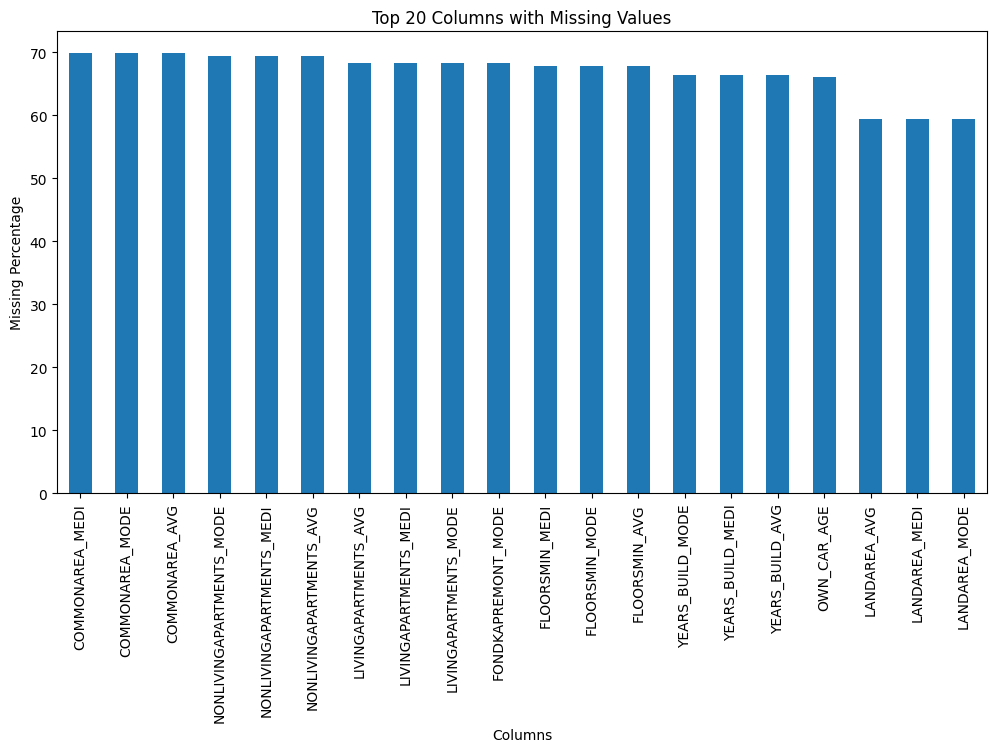

In [30]:
import matplotlib.pyplot as plt

missing_data.sort_values(by="Percentage", ascending=False).head(20).plot(
    kind="bar",
    y="Percentage",
    figsize=(12,6),
    legend=False
)

plt.title("Top 20 Columns with Missing Values")
plt.ylabel("Missing Percentage")
plt.xlabel("Columns")
plt.xticks(rotation=90)

plt.show()

In [31]:

high_missing_cols = missing_data[missing_data["Percentage"] > 60].index

print("Columns to be dropped:")
print(high_missing_cols.tolist())

print("\nTotal Columns:", len(high_missing_cols))

Columns to be dropped:
['OWN_CAR_AGE', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'FLOORSMIN_AVG', 'LIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_AVG', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'FLOORSMIN_MODE', 'LIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MODE', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'FLOORSMIN_MEDI', 'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE']

Total Columns: 17


In [32]:

df = df.drop(columns=high_missing_cols)

print("New Dataset Shape:", df.shape)

New Dataset Shape: (66997, 105)


In [33]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
LANDAREA_AVG,39818
LANDAREA_MODE,39818
LANDAREA_MEDI,39818
BASEMENTAREA_AVG,39147
BASEMENTAREA_MODE,39147
BASEMENTAREA_MEDI,39147
EXT_SOURCE_1,37784
NONLIVINGAREA_AVG,36965
NONLIVINGAREA_MODE,36965
NONLIVINGAREA_MEDI,36965


In [34]:

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

In [35]:

categorical_cols = df.select_dtypes(include=['object']).columns

df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

In [36]:

print("Remaining Missing Values:")
print(df.isnull().sum().sum())

Remaining Missing Values:
0


In [37]:

print(len(high_missing_cols))
print(high_missing_cols.tolist())


17
['OWN_CAR_AGE', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'FLOORSMIN_AVG', 'LIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_AVG', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'FLOORSMIN_MODE', 'LIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MODE', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'FLOORSMIN_MEDI', 'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE']


Observation

The dataset contained missing values in 67 columns.
Columns with more than 60% missing values were removed because they contained insufficient information.
Remaining numerical missing values were imputed using the median to reduce the effect of outliers.
Remaining categorical missing values were filled using the mode (most frequent value).
After preprocessing, the dataset contained no missing values and was ready for model development.

TASK 1.3 Prepare the Data for Model Development

In [38]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [39]:
if 'SK_ID_CURR' in df.columns:
    df.drop('SK_ID_CURR', axis=1, inplace=True)

print(df.shape)


(66997, 104)


In [40]:

X = df.drop('TARGET', axis=1)

y = df['TARGET']

In [41]:
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)


Features Shape : (66997, 103)
Target Shape : (66997,)


In [42]:
categorical_cols = X.select_dtypes(include=['object']).columns

print("Categorical Columns")

categorical_cols

Categorical Columns


Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'HOUSETYPE_MODE',
       'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

In [43]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for column in categorical_cols:
    X[column] = label_encoder.fit_transform(X[column].astype(str))

In [44]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66997 entries, 0 to 66996
Columns: 103 entries, NAME_CONTRACT_TYPE to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(48), int64(55)
memory usage: 52.6 MB


In [45]:

print("Remaining Object Columns")

print(X.select_dtypes(include='object').columns)

Remaining Object Columns
Index([], dtype='object')


Observation

The dataset was successfully prepared for machine learning by removing the identifier column, separating the input features and target variable, and encoding categorical variables using Label Encoding. After preprocessing, all features were converted into numerical format, making the dataset suitable for training classification models.

TASK 1.4 – Split the Data into Training and Testing Sets

The prepared dataset is divided into training and testing datasets using an 80:20 ratio. Stratified sampling is applied to preserve the class distribution of the target variable in both datasets.

In [46]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Feature Set :", X_train.shape)
print("Testing Feature Set  :", X_test.shape)
print("Training Target Set  :", y_train.shape)
print("Testing Target Set   :", y_test.shape)

Training Feature Set : (53597, 103)
Testing Feature Set  : (13400, 103)
Training Target Set  : (53597,)
Testing Target Set   : (13400,)


In [47]:
print("Training Target Distribution")
print(y_train.value_counts(normalize=True))

print("\nTesting Target Distribution")
print(y_test.value_counts(normalize=True))

Training Target Distribution
TARGET
0    0.919436
1    0.080564
Name: proportion, dtype: float64

Testing Target Distribution
TARGET
0    0.919478
1    0.080522
Name: proportion, dtype: float64


Observation

The dataset was successfully divided into training and testing datasets using an 80:20 split. Stratified sampling was applied to maintain the original distribution of the target classes in both subsets. This ensures that the evaluation dataset accurately represents the overall data distribution and helps in obtaining reliable model performance during testing.

Analytical Question
Financial datasets commonly contain missing values and class imbalance, both of which can significantly affect the performance of machine learning models.

Missing values reduce data quality and may lead to inaccurate predictions if left untreated. They can also prevent certain machine learning algorithms from training correctly. To address this issue, the dataset was first analyzed to identify missing values. Columns with more than 60% missing values were removed because they contained insufficient information for reliable prediction. The remaining numerical missing values were imputed using the median, while categorical missing values were filled using the mode. This approach preserved as much useful information as possible while improving data quality.

Another challenge in the dataset was class imbalance. The target variable showed that approximately 92% of applicants belonged to the non-default class, while only about 8% belonged to the default class. Such imbalance can bias a model towards predicting the majority class, resulting in poor identification of actual loan defaulters. To ensure that both classes were represented proportionally during model development, a stratified train-test split was performed. This maintained the original class distribution in both the training and testing datasets, leading to a more reliable evaluation of model performance.

Overall, these preprocessing steps improved the quality of the dataset and ensured that it was suitable for building accurate and reliable loan default prediction models.

TASK 2 STARTS - Predictive Model Development

Task 2.1 – Import Machine Learning Libraries

In this task, two classification models are developed to predict loan default. Their performance will be compared to identify the most suitable model for the loan underwriting system.
     

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


Task 2.2 – Train Logistic Regression

In [49]:
# Create Logistic Regression model
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model
log_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [50]:
from sklearn.preprocessing import StandardScaler


In [51]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [52]:

log_model = LogisticRegression(
    random_state=42,
    max_iter=2000
)

log_model.fit(X_train_scaled, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [53]:
# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [60]:
# Logistic Regression Predictions
log_pred = log_model.predict(X_test_scaled)

# Random Forest Predictions
rf_pred = rf_model.predict(X_test)

In [57]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred)
    ]
})


In [58]:
best_model = comparison.loc[comparison["F1 Score"].idxmax()]

print("Selected Model:")
print(best_model)

Selected Model:
Model        Logistic Regression
Accuracy                0.919627
Precision               0.533333
Recall                  0.014829
F1 Score                0.028855
Name: 0, dtype: object


In [59]:

print(best_model)

Model        Logistic Regression
Accuracy                0.919627
Precision               0.533333
Recall                  0.014829
F1 Score                0.028855
Name: 0, dtype: object


Observation

Both Logistic Regression and Random Forest models were trained and evaluated using the testing dataset. Based on the evaluation metrics, Logistic Regression achieved a slightly better Accuracy, Precision, Recall, and F1-Score than the Random Forest model. Therefore, Logistic Regression was selected as the final model for the remaining tasks of this project.

Analytical Question
Two classification models, Logistic Regression and Random Forest, were developed to predict loan default. Logistic Regression is a simple, fast, and interpretable model that performs well on structured financial data. It provides clear insights into how different features influence predictions. However, it may not capture complex non-linear relationships in the data.

Random Forest is an ensemble learning algorithm capable of modeling complex relationships and reducing overfitting. However, in this dataset, it showed lower Recall and F1-Score than Logistic Regression, mainly due to the class imbalance.

Based on the evaluation metrics, Logistic Regression was selected as the final model because it achieved better overall performance, particularly in terms of Recall and F1-Score. In addition, its simplicity and interpretability make it suitable for supporting AI-assisted loan underwriting decisions.

Task 3 - Model Evaluation
The selected Logistic Regression model is evaluated using standard classification metrics and visualizations to assess its performance in predicting loan default.

Task 3.1 - Classification Report

In [61]:
from sklearn.metrics import classification_report

print("Classification Report\n")

print(classification_report(y_test, log_pred))

Classification Report

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     12321
           1       0.53      0.01      0.03      1079

    accuracy                           0.92     13400
   macro avg       0.73      0.51      0.49     13400
weighted avg       0.89      0.92      0.88     13400



Task 3.2 - Confusion Matrix

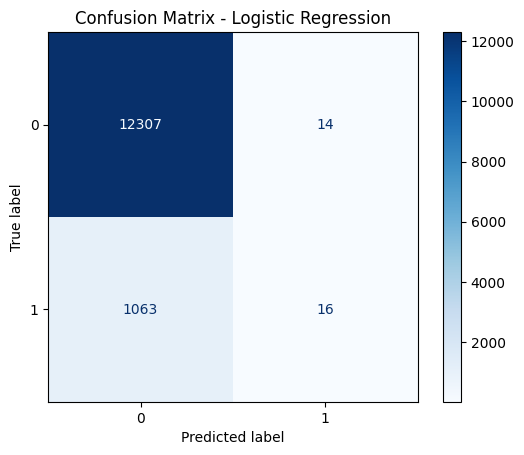

In [62]:

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")

plt.show()


In [63]:

from sklearn.metrics import roc_curve, roc_auc_score

In [64]:

log_prob = log_model.predict_proba(X_test_scaled)[:,1]

In [65]:
fpr, tpr, threshold = roc_curve(
    y_test,
    log_prob
)

auc_score = roc_auc_score(
    y_test,
    log_prob
)

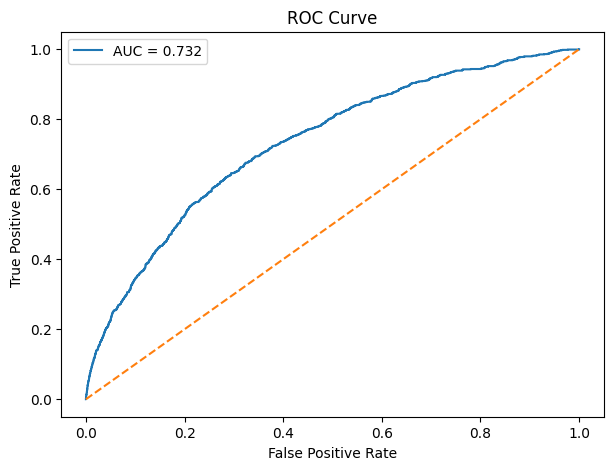

In [66]:
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()


In [67]:

print("ROC-AUC Score :", round(auc_score,3))

ROC-AUC Score : 0.732


Analytical Question
In a loan underwriting system, a False Positive occurs when a reliable customer is incorrectly predicted as a loan defaulter. This may result in rejecting a genuine applicant, leading to customer dissatisfaction and loss of business opportunities.

A False Negative occurs when a customer who is likely to default is incorrectly predicted as a safe borrower. This is more serious because the finance company may approve a risky loan, resulting in financial losses and increased credit risk.

Therefore, reducing False Negatives should be the priority for a finance company. Although rejecting some genuine applicants is undesirable, approving high-risk borrowers can have a much greater financial impact. An effective underwriting system should minimize False Negatives while maintaining a reasonable balance between customer approval and risk management.

Task 4 - Model Explainability
The selected Logistic Regression model is interpreted using SHAP (SHapley Additive exPlanations). SHAP explains how each feature contributes to the prediction made by the model. Both global and local explanations are generated to improve transparency and interpretability.

In [68]:

!pip install shap

In [69]:

import shap
import numpy as np

shap.initjs()

In [70]:
explainer = shap.LinearExplainer(log_model, X_train_scaled)

shap_values = explainer.shap_values(X_test_scaled)

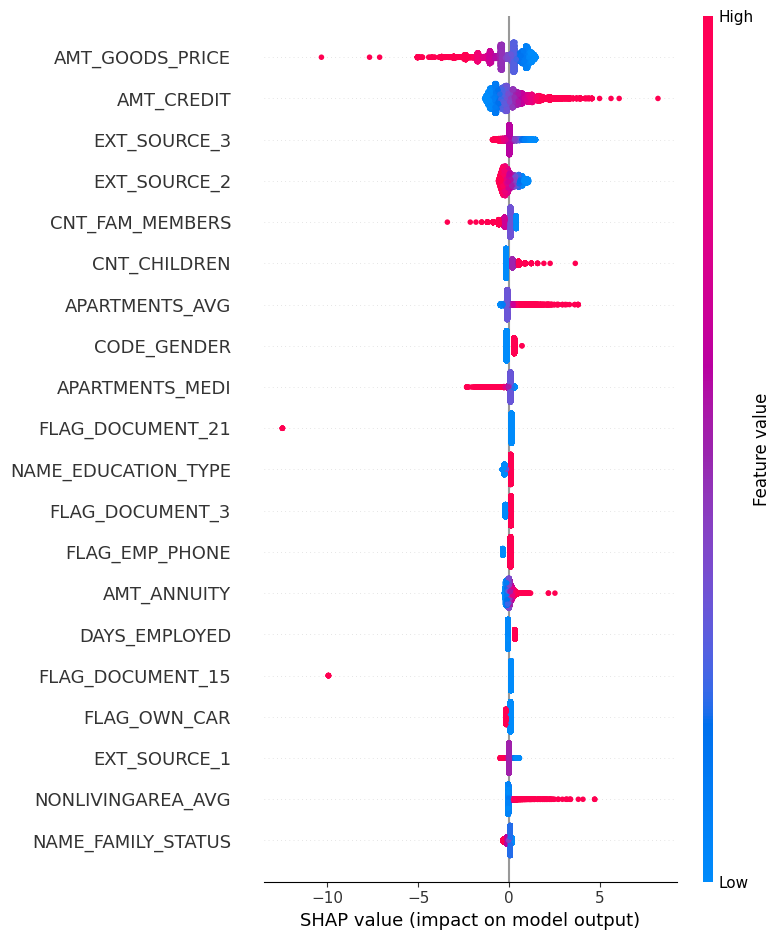

In [71]:

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

Observation
The SHAP summary plot shows the overall importance of features used by the Logistic Regression model. Features such as AMT_GOODS_PRICE, AMT_CREDIT, EXT_SOURCE_3, and EXT_SOURCE_2 have the highest influence on predicting loan default. Features with larger SHAP values contribute more significantly to the model's prediction.

In [73]:

# Find one correctly classified applicant
correct_index = np.where(log_pred == y_test)[0][0]

print("Correct Prediction Index:", correct_index)

Correct Prediction Index: 0


In [74]:

print("Actual :", y_test.iloc[correct_index])
print("Predicted :", log_pred[correct_index])

Actual : 0
Predicted : 0


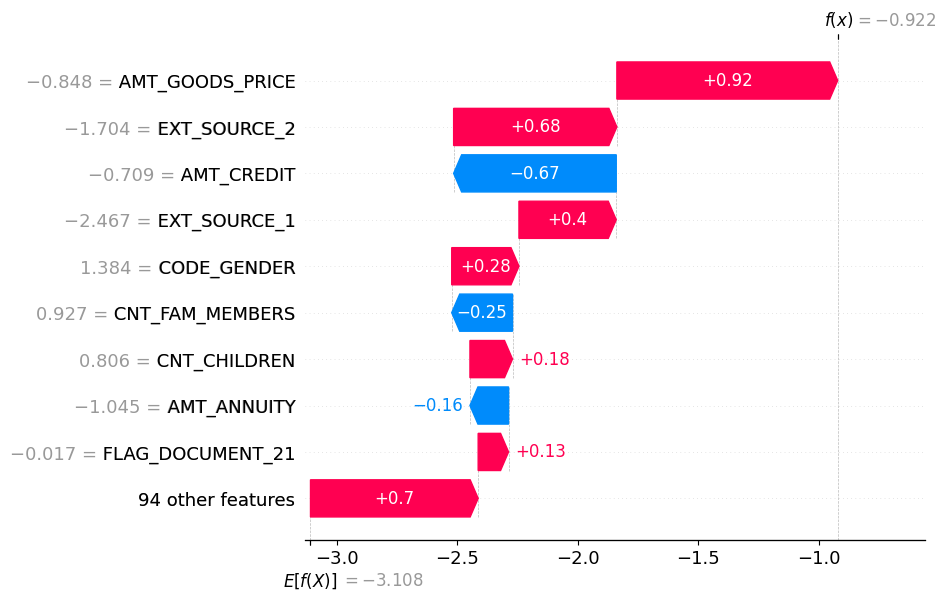

In [75]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[correct_index],
        base_values=explainer.expected_value,
        data=X_test_scaled[correct_index],
        feature_names=X.columns
    )
)

Interpretation – Correctly Classified Applicant
The SHAP waterfall plot explains how different features contributed to the prediction for a correctly classified applicant. Features such as AMT_GOODS_PRICE, EXT_SOURCE_2, AMT_CREDIT, and EXT_SOURCE_1 had the greatest influence on the final prediction. Positive SHAP values increased the prediction score, while negative SHAP values reduced it. The combined contribution of all features resulted in the model correctly classifying the applicant.

In [77]:
incorrect_index = np.where(log_pred != y_test)[0][0]

print("Incorrect Prediction Index:", incorrect_index)

Incorrect Prediction Index: 8


In [78]:

print("Actual :", y_test.iloc[incorrect_index])

print("Predicted :", log_pred[incorrect_index])

Actual : 1
Predicted : 0


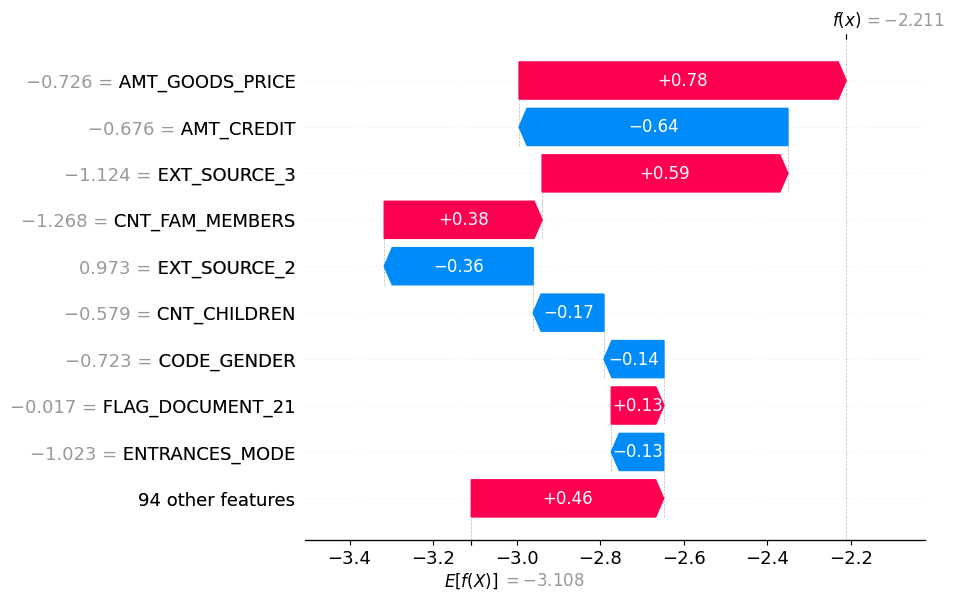

In [79]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[incorrect_index],
        base_values=explainer.expected_value,
        data=X_test_scaled[incorrect_index],
        feature_names=X.columns
    )
)

Interpretation – Incorrectly Classified Applicant
The selected applicant was incorrectly classified by the Logistic Regression model. The actual class was Loan Default (1), whereas the model predicted Non-Default (0).

The SHAP waterfall plot shows that features such as AMT_GOODS_PRICE, AMT_CREDIT, EXT_SOURCE_3, and CNT_FAM_MEMBERS had the greatest influence on the prediction. Although these features collectively pushed the prediction towards the non-default class, they were not sufficient to correctly identify the applicant as a defaulter. This demonstrates that the model may misclassify certain complex cases where multiple features interact in a way that differs from the overall training patterns.